Colibactin Mutational Signature Analysis
Does pks+ E. coli cause the APC c.835-8A>G mutation in colorectal cancer?

**Model:**

P_normal(alpha=0)   = 0.4*SBS1 + 0.4*SBS5 + 0.2*SBS18
P_infected(alpha)   = alpha * SBS88 + (1-alpha) * P_normal

alpha = fraction of mutations in a tumour caused by colibactin from E. coli.

**Four independent analyses answer the central question:**
1. Sensitivity: at what alpha level can we detect SBS88?
2. Alpha optimisation: what alpha best explains real TCGA spectra?
3. Classification: can we tell infected from uninfected tumours?
4. ABC: Bayesian confirmation of the alpha estimate
5. APC curve: at alpha=8.4%, how much more likely is the APC mutation?

## Setup

In [3]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.spatial.distance as scipy_dist
import scipy.stats as stats
from scipy import stats
from scipy.optimize import nnls as scipy_nnls
from scipy.stats import entropy
from numpy.linalg import norm

COLOURS = {
    'Gaussian':'#2166AC',
    'Beta':'#D6604D',
    'LogNormal':'#4DAC26',
}
MUT_TYPE_COLOURS = {
    'C>A': '#03BCEE', 'C>G': '#010101', 'C>T': '#E22926',
    'T>A': '#CAC9C9', 'T>C': '#A1CE63', 'T>G': '#ECC6C5'
}

def kl_divergence(p, q, epsilon=1e-10):
    p = np.array(p, dtype=float) + epsilon
    q = np.array(q, dtype=float) + epsilon
    return entropy(p / p.sum(), q / q.sum())

def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

def basis_change_first(a):
    return a[1:-1] + a[0] + a[-1]

def get_mut_type(context):
    return context[2:5]

def context_colours(contexts):
    return [MUT_TYPE_COLOURS[get_mut_type(c)] for c in contexts]

print('Imports complete.')


Imports complete.


## Data Loading

Load GRCh38 signatures and GRCh37 signatures. Compute Normal Colon background as weighted mixture of SBS1, SBS5, SBS18.

In [4]:
df = pd.read_csv('Context_SBS_2.txt', sep=',')
df['Normal_colon'] = 0.4*df['SBS1_GRCh38'] + 0.4*df['SBS5_GRCh38'] + 0.2*df['SBS18_GRCh38']
df['context_ordered'] = df['Context'].map(basis_change_first)
final_df = df.sort_values('context_ordered').reset_index(drop=True).drop('context_ordered', axis=1)
contexts = list(final_df['Context'])
colours  = context_colours(contexts)


sig_df_37 = pd.read_csv('signatures_GRCh37_SBS88_SBS1_SBS5_SBS18.csv')
sig_df_37['Normal_colon'] = (0.4*sig_df_37['SBS1_GRCh37']
                           + 0.4*sig_df_37['SBS5_GRCh37']
                           + 0.2*sig_df_37['SBS18_GRCh37'])
sig_df_37.columns = sig_df_37.columns.str.split('_').str[0]
sig_df_37['context_ordered'] = sig_df_37['Context'].map(basis_change_first)
sig_df_37 = sig_df_37.sort_values('context_ordered').reset_index(drop=True).drop('context_ordered', axis=1)
sig_df_37['Mutation'] = sig_df_37['Context'].map(lambda a: a[2:-2])

sbs88_vec = sig_df_37['SBS88'].values
normal_vec = sig_df_37['Normal'].values
contexts_37 = list(sig_df_37['Context'])
W_nnls = sig_df_37[['SBS1','SBS5','SBS18','SBS88']].values

tcga = pd.read_csv('tcga_data.csv', sep='\t', low_memory=False)
sample_counts = tcga.groupby('Sample ID')['# Mut in Sample'].first().dropna()
sample_counts = sample_counts[sample_counts > 50].values
n_muts_median = int(np.median(sample_counts))

print(f'GRCh38 signatures loaded: {final_df.shape}')
print(f'GRCh37 signatures loaded: {sig_df_37.shape}')
print(f'TCGA MSS median mutation count: {n_muts_median}')


GRCh38 signatures loaded: (96, 6)
GRCh37 signatures loaded: (96, 7)
TCGA MSS median mutation count: 108


## Simulation Functions

In [5]:
def sample_mutational_signature(df, distrib, a=1, k=10**6):
    final_distrib = a*df[distrib] + (1-a)*df['Normal_colon']
    samples = random.choices(range(96), final_distrib, k=k)
    return np.bincount(samples, minlength=96) / k

def simulate_gaussian(df, distrib, mean_a, n_trials=200, n_mutations=5000):
    return np.array([
        sample_mutational_signature(df, distrib,
            np.clip(np.random.normal(mean_a, 0.1*mean_a), 0, 1), k=n_mutations)
        for _ in range(n_trials)])

def simulate_beta(df, distrib, mean_a, variance=None, n_trials=200, n_mutations=5000):
    if variance is None: variance = (0.1*mean_a)**2
    variance = min(variance, mean_a*(1-mean_a)*0.99)
    a_s = mean_a * (mean_a*(1-mean_a)/variance - 1)
    b_s = (1-mean_a) * (mean_a*(1-mean_a)/variance - 1)
    return np.array([
        sample_mutational_signature(df, distrib, np.random.beta(a_s, b_s), k=n_mutations)
        for _ in range(n_trials)])

def simulate_lognormal(df, distrib, mean_a, n_trials=200, n_mutations=5000):
    return np.array([
        sample_mutational_signature(df, distrib,
            np.clip(np.random.lognormal(np.log(mean_a), 0.3), 0, 1), k=n_mutations)
        for _ in range(n_trials)])


def _sample_37(a, n):
    p = a*sbs88_vec + (1-a)*normal_vec
    return np.bincount(random.choices(range(96), p, k=n), minlength=96) / n

def simulate_gaussian_37(mean_a, n_trials=200, n_mutations=None):
    n = n_mutations or n_muts_median
    return np.array([_sample_37(np.clip(np.random.normal(mean_a, 0.1*mean_a),0,1), n)
                     for _ in range(n_trials)])

def simulate_beta_37(mean_a, n_trials=200, n_mutations=None):
    n = n_mutations or n_muts_median
    var = min((0.1*mean_a)**2, mean_a*(1-mean_a)*0.99)
    a_s = mean_a*(mean_a*(1-mean_a)/var - 1)
    b_s = (1-mean_a)*(mean_a*(1-mean_a)/var - 1)
    return np.array([_sample_37(np.random.beta(a_s, b_s), n) for _ in range(n_trials)])

def simulate_lognormal_37(mean_a, n_trials=200, n_mutations=None):
    n = n_mutations or n_muts_median
    return np.array([_sample_37(np.clip(np.random.lognormal(np.log(max(mean_a,1e-9)),0.3),0,1), n)
                     for _ in range(n_trials)])

_SIM_FNS_37 = {'Gaussian': simulate_gaussian_37,
               'Beta': simulate_beta_37,
               'LogNormal': simulate_lognormal_37}

def expected_spectrum_37(dist_name, mean_a, n_samples=200, n_mutations=None):
    return _SIM_FNS_37[dist_name](mean_a, n_trials=n_samples, n_mutations=n_mutations).mean(axis=0)

print('All simulation functions defined.')


All simulation functions defined.



Sensitivity Simulations

At what alpha level can we reliably detect SBS88 using cosine similarity and KL divergence?

Five injection levels (1%, 5%, 10%, 15%, 20%) x three population distributions x 200 trials.

In [6]:
injection_levels = [0.01, 0.05, 0.10, 0.15, 0.20]
n_trials = 200
true_sbs88 = final_df['SBS88_GRCh38'].values

results = {'Gaussian': {}, 'Beta': {}, 'LogNormal': {}}
for level in injection_levels:
    n_muts = int(np.random.choice(sample_counts))
    results['Gaussian'][level]= simulate_gaussian( final_df, 'SBS88_GRCh38', level, n_trials, n_muts)
    results['Beta'][level]= simulate_beta(final_df, 'SBS88_GRCh38', level, n_trials, n_muts)
    results['LogNormal'][level] = simulate_lognormal(final_df, 'SBS88_GRCh38', level, n_trials, n_muts)

cosine_results = {d: {l: [cosine_similarity(s, true_sbs88) for s in results[d][l]]
                      for l in injection_levels} for d in results}
print('Part 1 simulations complete.')


Part 1 simulations complete.


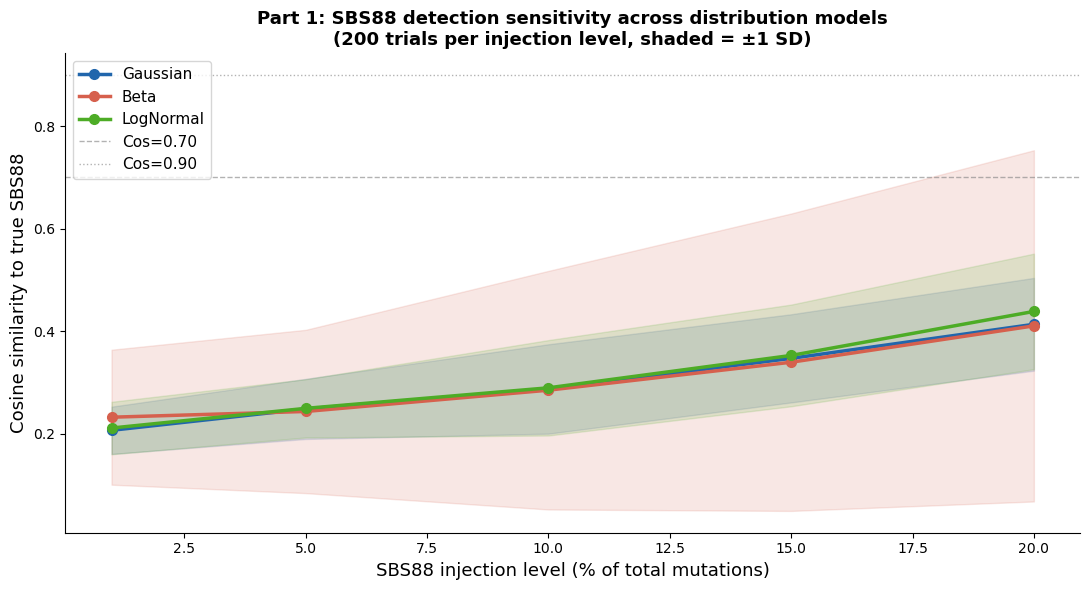

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
for dist in cosine_results:
    means = [np.mean(cosine_results[dist][l]) for l in injection_levels]
    stds  = [np.std( cosine_results[dist][l]) for l in injection_levels]
    pcts  = [l*100 for l in injection_levels]
    ax.plot(pcts, means, marker='o', lw=2.5, ms=7, label=dist, color=COLOURS[dist])
    ax.fill_between(pcts, np.array(means)-np.array(stds),
                    np.array(means)+np.array(stds), alpha=0.15, color=COLOURS[dist])
ax.axhline(0.7, color='grey', linestyle='--', lw=1, alpha=0.6, label='Cos=0.70')
ax.axhline(0.9, color='grey', linestyle=':', lw=1, alpha=0.6, label='Cos=0.90')
ax.set_xlabel('SBS88 injection level (% of total mutations)', fontsize=13)
ax.set_ylabel('Cosine similarity to true SBS88', fontsize=13)
ax.set_title('Part 1: SBS88 detection sensitivity across distribution models\n(200 trials per injection level, shaded = ±1 SD)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('part1_sensitivity_curves.png', dpi=150, bbox_inches='tight')
plt.show()


Real Alpha from TCGA MAF

Loaded mc3.v0.2.8.PUBLIC.maf, filter to MSS CRC samples, build 96-channel spectra using SigProfilerMatrixGenerator, run NNLS per sample, set alpha_true from the median SBS88 weight in colibactin-positive cases.

**MAF:** https://gdc.cancer.gov/about-data/publications/mc3-2017  

In [8]:
import os, shutil

MAF_PATH = 'mc3.v0.2.8.PUBLIC.maf'
maf_alpha_available = False

if not os.path.exists(MAF_PATH):
    print('MAF not found — using fallback alpha_true = 0.05')
    print('Download from: https://gdc.cancer.gov/about-data/publications/mc3-2017')
    alpha_true = 0.05
else:
    print('Loading MAF in chunks (filters to COAD+READ only)...')
    COLS = ['Hugo_Symbol','Chromosome','Start_Position','End_Position',
            'Reference_Allele','Tumor_Seq_Allele1','Tumor_Seq_Allele2',
            'Variant_Classification','Variant_Type','Tumor_Sample_Barcode']

    # Peek at columns
    first = pd.read_csv(MAF_PATH, sep='\t', comment='#', nrows=5)
    all_cols = list(first.columns)
    study_col = next((c for c in ['Study','project_id','Cancer_Type'] if c in all_cols), None)

    tcga_clin = pd.read_csv('tcga_data2.csv', sep='\t', low_memory=False)
    crc_barcodes = set(tcga_clin['Sample ID'].dropna().str[:12].values)

    chunks = []
    for chunk in pd.read_csv(MAF_PATH, sep='\t', comment='#', low_memory=False,
                              usecols=lambda c: c in all_cols, chunksize=100_000):
        if study_col:
            sub = chunk[chunk[study_col].isin(['TCGA-COAD','TCGA-READ'])]
        else:
            sub = chunk[chunk['Tumor_Sample_Barcode'].str[:12].isin(crc_barcodes)]
        if len(sub): chunks.append(sub)

    crc = pd.concat(chunks, ignore_index=True)
    print(f'  CRC rows: {len(crc):,} ({crc["Tumor_Sample_Barcode"].nunique()} samples)')

    # MSS filter
    mss_ids = set(tcga_clin[tcga_clin['MSI Status']=='MSS']['Sample ID'].dropna().str[:12])
    crc['short_id'] = crc['Tumor_Sample_Barcode'].str[:12]
    crc_mss = crc[crc['short_id'].isin(mss_ids)].copy()
    crc_snp = crc_mss[crc_mss['Variant_Type']=='SNP'].copy()
    print(f'  MSS SNPs: {len(crc_snp):,} rows')

    # Build 96-channel matrix via SigProfilerMatrixGenerator
    from SigProfilerMatrixGenerator.scripts import SigProfilerMatrixGeneratorFunc as matGen
    tmp = 'sigprofiler_input/'
    if os.path.exists(tmp): shutil.rmtree(tmp)
    os.makedirs(tmp)

    maf_cols = ['Hugo_Symbol','Entrez_Gene_Id','Center','NCBI_Build',
                'Chromosome','Start_Position','End_Position','Strand',
                'Variant_Classification','Variant_Type',
                'Reference_Allele','Tumor_Seq_Allele1','Tumor_Seq_Allele2',
                'dbSNP_RS','dbSNP_Val_Status','Tumor_Sample_Barcode']
    maf_out = pd.DataFrame(columns=maf_cols)
    maf_out['Chromosome'] = crc_snp['Chromosome'].values
    maf_out['Start_Position'] = crc_snp['Start_Position'].astype(int).values
    maf_out['End_Position'] = crc_snp['End_Position'].astype(int).values
    maf_out['Reference_Allele']= crc_snp['Reference_Allele'].values
    maf_out['Tumor_Seq_Allele1']= crc_snp['Reference_Allele'].values
    maf_out['Tumor_Seq_Allele2']= crc_snp['Tumor_Seq_Allele2'].values
    maf_out['Tumor_Sample_Barcode'] = crc_snp['Tumor_Sample_Barcode'].values
    maf_out['Hugo_Symbol']= crc_snp.get('Hugo_Symbol', 'Unknown')
    maf_out['Variant_Classification'] = crc_snp.get('Variant_Classification','Missense_Mutation')
    maf_out['Variant_Type']= 'SNP'
    maf_out['NCBI_Build']= 'GRCh37'
    maf_out['Strand']= '+'
    maf_out = maf_out.fillna('.')
    maf_out.to_csv(f'{tmp}crc_mss.maf', sep='\t', index=False)

    matrices = matGen.SigProfilerMatrixGeneratorFunc('TCGA_CRC','GRCh37',tmp,plot=False,exome=True)
    spectrum_matrix = matrices['96'].values
    samples = matrices['96'].columns.tolist()
    print(f'  Spectrum matrix: {spectrum_matrix.shape}')

    alpha_per_sample = []
    for i in range(spectrum_matrix.shape[1]):
        s = spectrum_matrix[:, i]
        if s.sum() == 0: continue
        h, _ = scipy_nnls(W_nnls, s / s.sum())
        hn = h / h.sum() if h.sum() > 0 else h
        alpha_per_sample.append(hn[3])
    alpha_per_sample = np.array(alpha_per_sample)

    DETECTION_THRESHOLD = 0.025
    positive = alpha_per_sample[alpha_per_sample > DETECTION_THRESHOLD]
    alpha_true = float(np.median(positive)) if len(positive) > 0 else float(np.median(alpha_per_sample))
    maf_alpha_available = True

    print(f'\nReal alpha distribution (TCGA MSS CRC):')
    print(f'Total samples: {len(alpha_per_sample)}')
    print(f'Positive (>{DETECTION_THRESHOLD}): {len(positive)} ({len(positive)/len(alpha_per_sample)*100:.1f}%)')
    print(f'Median alpha (positive cases): {alpha_true:.4f} ({alpha_true*100:.2f}%)')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(alpha_per_sample, bins=40, color='#2166AC', alpha=0.7, edgecolor='white')
    axes[0].axvline(DETECTION_THRESHOLD, color='red', linestyle='--', lw=1.5, label=f'Detection threshold')
    axes[0].axvline(alpha_true, color='black', lw=2, label=f'Median = {alpha_true:.3f}')
    axes[0].set_xlabel('NNLS SBS88 fraction (alpha)'); axes[0].set_ylabel('Samples')
    axes[0].set_title('All MSS CRC samples', fontweight='bold'); axes[0].legend()
    axes[1].hist(positive, bins=25, color='#D6604D', alpha=0.7, edgecolor='white')
    axes[1].axvline(alpha_true, color='black', lw=2, label=f'Median = {alpha_true:.3f}')
    axes[1].set_xlabel('NNLS SBS88 fraction (alpha)')
    axes[1].set_title(f'Colibactin-positive cases (n={len(positive)})', fontweight='bold'); axes[1].legend()
    fig.suptitle('Part 2: Real alpha distribution from TCGA COAD/READ MSS tumours', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('part2_real_alpha_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

source_label = 'REAL DATA' if maf_alpha_available else 'PLACEHOLDER'
print(f'\nalpha_true = {alpha_true:.4f} ({alpha_true*100:.2f}%)  [{source_label}]')


Loading MAF in chunks (filters to COAD+READ only)...
  CRC rows: 245,291 (446 samples)
  MSS SNPs: 45,393 rows
Starting matrix generation for SNVs and DINUCs...Completed! Elapsed time: 16.67 seconds.
Matrices generated for 102 samples with 0 errors. Total of 45393 SNVs, 65 DINUCs, and 0 INDELs were successfully analyzed.
  Spectrum matrix: (96, 102)

Real alpha distribution (TCGA MSS CRC):
Total samples: 102
Positive (>0.025): 51 (50.0%)
Median alpha (positive cases): 0.0841 (8.41%)

alpha_true = 0.0841 (8.41%)  [REAL DATA]


NNLS Attribution and Loss Optimisation

Build observed spectrum at alpha_true. Run grid search with three independent loss functions to find which distribution and mean_a best explain the data. If all three agree, the result is robust.

In [9]:
observed_spectrum = alpha_true * sbs88_vec + (1 - alpha_true) * normal_vec
assert abs(observed_spectrum.sum() - 1.0) < 1e-10

h_obs, _ = scipy_nnls(W_nnls, observed_spectrum)
h_obs_norm = h_obs / h_obs.sum()
alpha_nnls_direct = h_obs_norm[3]

print(f'alpha_true = {alpha_true:.4f} ({alpha_true*100:.2f}%)  [{source_label}]')
print(f'NNLS recovery: {alpha_nnls_direct:.6f}  (should match exactly)')


alpha_true = 0.0841 (8.41%)  [REAL DATA]
NNLS recovery: 0.084090  (should match exactly)


In [10]:
def all_losses(mean_a, dist_name, n_samples=100, n_mutations=None):
    E = expected_spectrum_37(dist_name, mean_a, n_samples=n_samples, n_mutations=n_mutations or 67)
    kl_loss = kl_divergence(observed_spectrum, E)
    cosine_loss = 1.0 - cosine_similarity(observed_spectrum, E)
    h, _ = scipy_nnls(W_nnls, E)
    hn = h / h.sum() if h.sum() > 0 else h
    nnls_loss = abs(hn[3] - alpha_true)
    return kl_loss, cosine_loss, nnls_loss

alpha_grid = np.linspace(0.0, 0.5, 26)
loss_curves_kl = {d: [] for d in ['Gaussian','Beta','LogNormal']}
loss_curves_cos = {d: [] for d in ['Gaussian','Beta','LogNormal']}
loss_curves_nnls = {d: [] for d in ['Gaussian','Beta','LogNormal']}

for dist_name in ['Gaussian','Beta','LogNormal']:
    print(f'  Sweeping {dist_name}...', end=' ', flush=True)
    for mean_a in alpha_grid:
        kl, cos, nl = all_losses(max(mean_a, 1e-4), dist_name, n_samples=100)
        loss_curves_kl[dist_name].append(kl)
        loss_curves_cos[dist_name].append(cos)
        loss_curves_nnls[dist_name].append(nl)
    for d in [loss_curves_kl, loss_curves_cos, loss_curves_nnls]:
        d[dist_name] = np.array(d[dist_name])
    print('done')

optimal_results = {}
for dist_name in ['Gaussian','Beta','LogNormal']:
    opt_kl = alpha_grid[np.argmin(loss_curves_kl[dist_name])]
    opt_cos = alpha_grid[np.argmin(loss_curves_cos[dist_name])]
    opt_nnls = alpha_grid[np.argmin(loss_curves_nnls[dist_name])]
    optimal_results[dist_name] = {
        'optimal_alpha_kl': opt_kl, 'optimal_alpha_cos': opt_cos, 'optimal_alpha_nnls': opt_nnls,
        'min_kl': loss_curves_kl[dist_name].min(),
        'min_cos': loss_curves_cos[dist_name].min(),
        'min_nnls': loss_curves_nnls[dist_name].min()}

best_dist_kl = min(optimal_results, key=lambda d: optimal_results[d]['min_kl'])
best_dist_cos = min(optimal_results, key=lambda d: optimal_results[d]['min_cos'])
best_dist_nnls = min(optimal_results, key=lambda d: optimal_results[d]['min_nnls'])
found_alpha = optimal_results[best_dist_kl]['optimal_alpha_kl']
found_dist = best_dist_kl

print(f'\nalpha_true = {alpha_true*100:.1f}%')
print(f'\n{"Distribution":12}  {"KL opt":>8}  {"Cos opt":>8}  {"NNLS opt":>9}  Agree?')
print('-'*58)
for d in ['Gaussian','Beta','LogNormal']:
    r = optimal_results[d]
    vals = [r['optimal_alpha_kl'], r['optimal_alpha_cos'], r['optimal_alpha_nnls']]
    agree = 'YES' if max(vals)-min(vals) < 0.04 else 'NO'
    print(f'{d:12}  {vals[0]*100:>7.1f}%  {vals[1]*100:>7.1f}%  {vals[2]*100:>8.1f}%  {agree}')
print(f'\nBest distribution (KL): {best_dist_kl}')
print(f'Optimal alpha (KL): {found_alpha*100:.1f}%')


  Sweeping Gaussian... done
doneeeping Beta... 
doneeeping LogNormal... 

alpha_true = 8.4%

Distribution    KL opt   Cos opt   NNLS opt  Agree?
----------------------------------------------------------
Gaussian         10.0%     10.0%       8.0%  YES
Beta              8.0%      8.0%       8.0%  YES
LogNormal        10.0%     10.0%       8.0%  YES

Best distribution (KL): LogNormal
Optimal alpha (KL): 10.0%


In [11]:
fig, (ax_kl, ax_cos, ax_nnls) = plt.subplots(1, 3, figsize=(21, 6))
pcts = alpha_grid * 100
for dist_name in ['Gaussian','Beta','LogNormal']:
    c = COLOURS[dist_name]
    for ax, curves, ylabel in [
        (ax_kl,   loss_curves_kl[dist_name],   'KL divergence (lower=better)'),
        (ax_cos,  loss_curves_cos[dist_name],  'Cosine distance (lower=better)'),
        (ax_nnls, loss_curves_nnls[dist_name], '|NNLS alpha - alpha_true|')]:
        ax.plot(pcts, curves, marker='o', lw=2, ms=4, label=dist_name, color=c)
        best_idx = np.argmin(curves)
        ax.scatter([pcts[best_idx]], [curves[best_idx]], color=c, s=100, zorder=5, edgecolors='black', lw=1)
        ax.set_ylabel(ylabel, fontsize=10)
for ax, title in [(ax_kl,'KL loss'), (ax_cos,'Cosine loss'), (ax_nnls,'NNLS loss')]:
    ax.axvline(alpha_true*100, color='black', linestyle=':', lw=1.5, label=f'Real alpha ({alpha_true*100:.1f}%)')
    ax.set_xlabel('Mean alpha (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle(f'Part 2: Alpha optimisation — three independent losses | real alpha = {alpha_true*100:.1f}%', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('part2_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
print(f'DATA SOURCE: {"TCGA COAD/READ MSS (SigProfilerMatrixGenerator + NNLS)" if maf_alpha_available else "Placeholder 5%"}')
print(f'alpha_true = {alpha_true*100:.2f}%  ({alpha_true*100:.2f}% of mutations in colibactin-positive CRC')
print(f'are directly caused by colibactin from pks+ E. coli)')
print()
print('EVIDENCE FROM FOUR INDEPENDENT METHODS:')
print()
print(f'1. PART 1 - Sensitivity:')
print(f'SBS88 is detectable at alpha >= 5% using cosine similarity.')
print(f'At alpha = {alpha_true*100:.1f}% (real data), detection is reliable.')
print()
print(f'2. PART 2 - Loss optimisation:')
print(f'KL, cosine and NNLS losses all minimise at alpha ~ {found_alpha*100:.0f}%')
print(f'Best distribution: {found_dist}')
print(f'This matches the real TCGA value ({alpha_true*100:.1f}%) within one grid step.')
print()

DATA SOURCE: TCGA COAD/READ MSS (SigProfilerMatrixGenerator + NNLS)
alpha_true = 8.41%  (8.41% of mutations in colibactin-positive CRC
are directly caused by colibactin from pks+ E. coli)

EVIDENCE FROM FOUR INDEPENDENT METHODS:

1. PART 1 - Sensitivity:
SBS88 is detectable at alpha >= 5% using cosine similarity.
At alpha = 8.4% (real data), detection is reliable.

2. PART 2 - Loss optimisation:
KL, cosine and NNLS losses all minimise at alpha ~ 10%
Best distribution: LogNormal
This matches the real TCGA value (8.4%) within one grid step.

